In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from mechanisms.CoP.cop import CoP_Mechanism
from utils.cmf_pmf_cal import get_cmf_pmf_dict_with_alphabet
from utils.data_perturb import Perturbation
from utils.pmi_cal import get_pmi_dict
from utils.util_functions import validate_perturbed_data
from utils.eval_perturbed import Evaluate_Perturbed_Data
from utils.theoretical_privacy_leakage import thoeretical_privacy_leakage
from utils.compute_per_attribute_privacy_budget import get_per_attribute_privacy_budget
from utils.mi_compute import get_mi_dict

In [2]:

THR = 0.5
THR_mi = 0.0
ALPHA = 0.1

In [3]:

EPS_ARRAY = [1, 2, 4, 10, 15] 

FILE_LOCATION_LOAD = f"{os.getcwd()}/datasets/dummy.csv"
FILE_LOCATION_SAVE = f"{os.getcwd()}/results/dummy"
data = pd.read_csv(FILE_LOCATION_LOAD, sep=',', engine='python', dtype=int)

data = data.replace('?', pd.NA).dropna()
data.dropna(inplace=True)
data_samples = data.shape[0]
COLUMNS = data.columns.to_list()
CMF_dict, alphabet_dict = get_cmf_pmf_dict_with_alphabet(data=data, is_pmf=False)
mi_dict = get_mi_dict(data=data, COLUMNS=COLUMNS)
PMI_dict = get_pmi_dict(data=data)

cpm_mechanism = CoP_Mechanism(ordered_attribute_list=COLUMNS, alphabet_dict=alphabet_dict, THR=THR, CMF_dict=CMF_dict, pmi_dict=PMI_dict, mi_dict=mi_dict, THR_mi=THR_mi, ALPHA=ALPHA)

perturbation = Perturbation(data=data[COLUMNS], mechanism=cpm_mechanism, COLUMNS=COLUMNS, save_location=FILE_LOCATION_SAVE)

PER_ATTRIBUTE_EPS = []
observed_leakage = []
for eps in EPS_ARRAY:
    observed_leakage.append(thoeretical_privacy_leakage(CMF_dict=CMF_dict, COLUMNS=COLUMNS, eps=eps, location=FILE_LOCATION_SAVE, recompute = True, EPS=eps)[0])
privacy_leakage_dict = observed_leakage
eps_dict = EPS_ARRAY
for eps in EPS_ARRAY:
    PER_ATTRIBUTE_EPS.append(get_per_attribute_privacy_budget(eps=eps, eps_dict=eps_dict, privacy_leakage_dict=privacy_leakage_dict))
print("PER_ATTRIBUTE_EPS ", PER_ATTRIBUTE_EPS)

# perturbation.perturb(EPS_ARRAY=PER_ATTRIBUTE_EPS)

perturbed_data_list = []

for eps in PER_ATTRIBUTE_EPS:
    perturbed_data_location = f"{FILE_LOCATION_SAVE[:]}_perturbed_eps_{eps}.csv.zip"
    perturbed_data_list.append(pd.read_csv(perturbed_data_location, compression='zip', engine='python', dtype=str)[COLUMNS])
    print(f'{perturbed_data_location} loaded.')

original_len = data.shape[0]
validate_perturbed_data(original_len, COLUMNS, perturbed_data_list)
number_of_copies = int(np.shape(perturbed_data_list[0].values)[0]/original_len)

evaluation = Evaluate_Perturbed_Data(original_data=data[COLUMNS], EPS_ARRAY=EPS_ARRAY, COLUMNS=COLUMNS, perturbed_data_list=perturbed_data_list,
                                        save_location=FILE_LOCATION_SAVE, alphabet_dict=alphabet_dict, numerical=np.ones(len(COLUMNS)))

evaluation.evaluate_perturbed_data()

self.data[self.COLUMNS].values [[7 8 7 9 2]
 [4 0 6 9 3]
 [2 8 8 4 4]
 ...
 [8 2 1 9 0]
 [4 0 5 9 4]
 [5 5 4 9 4]]
xk  A  xl  B (10, 10)
xk  A  xl  C (10, 10)
xk  A  xl  D (10, 10)
xk  A  xl  E (10, 8)
num_attr num_rows 4 10
xk  B  xl  A (10, 10)
xk  B  xl  C (10, 10)
xk  B  xl  D (10, 10)
xk  B  xl  E (10, 8)
num_attr num_rows 4 10
xk  C  xl  A (10, 10)
xk  C  xl  B (10, 10)
xk  C  xl  D (10, 10)
xk  C  xl  E (10, 8)
num_attr num_rows 4 10
xk  D  xl  A (10, 10)
xk  D  xl  B (10, 10)
xk  D  xl  C (10, 10)
xk  D  xl  E (10, 8)
num_attr num_rows 4 10
xk  E  xl  A (8, 10)
xk  E  xl  B (8, 10)
xk  E  xl  C (8, 10)
xk  E  xl  D (8, 10)
num_attr num_rows 4 8
xk  A  xl  B (10, 10)
xk  A  xl  C (10, 10)
xk  A  xl  D (10, 10)
xk  A  xl  E (10, 8)
num_attr num_rows 4 10
xk  B  xl  A (10, 10)
xk  B  xl  C (10, 10)
xk  B  xl  D (10, 10)
xk  B  xl  E (10, 8)
num_attr num_rows 4 10
xk  C  xl  A (10, 10)
xk  C  xl  B (10, 10)
xk  C  xl  D (10, 10)
xk  C  xl  E (10, 8)
num_attr num_rows 4 10
xk  D  xl

/Users/sjay9734/Downloads/CoP-artifacts-PETS-main/utils/theoretical_privacy_leakage.py:6: RuntimeWarning: divide by zero encountered in divide
  Q = G/G_prime # np.sort(G/G_prime)[::-1]
/Users/sjay9734/Downloads/CoP-artifacts-PETS-main/utils/theoretical_privacy_leakage.py:6: RuntimeWarning: invalid value encountered in divide
  Q = G/G_prime # np.sort(G/G_prime)[::-1]


/Users/sjay9734/Downloads/CoP-artifacts-PETS-main/results/dummy_perturbed_eps_0.20562922668119898.csv.zip loaded.
/Users/sjay9734/Downloads/CoP-artifacts-PETS-main/results/dummy_perturbed_eps_0.4075166448390055.csv.zip loaded.
/Users/sjay9734/Downloads/CoP-artifacts-PETS-main/results/dummy_perturbed_eps_0.8112914811546187.csv.zip loaded.
/Users/sjay9734/Downloads/CoP-artifacts-PETS-main/results/dummy_perturbed_eps_2.0227866955349714.csv.zip loaded.
/Users/sjay9734/Downloads/CoP-artifacts-PETS-main/results/dummy_perturbed_eps_3.03984301481741.csv.zip loaded.
Saved  /Users/sjay9734/Downloads/CoP-artifacts-PETS-main/results/dummy_utility_evaluation_eps_1.pkl
Saved  /Users/sjay9734/Downloads/CoP-artifacts-PETS-main/results/dummy_utility_evaluation_eps_2.pkl
Saved  /Users/sjay9734/Downloads/CoP-artifacts-PETS-main/results/dummy_utility_evaluation_eps_4.pkl
Saved  /Users/sjay9734/Downloads/CoP-artifacts-PETS-main/results/dummy_utility_evaluation_eps_10.pkl
Saved  /Users/sjay9734/Downloads/Co

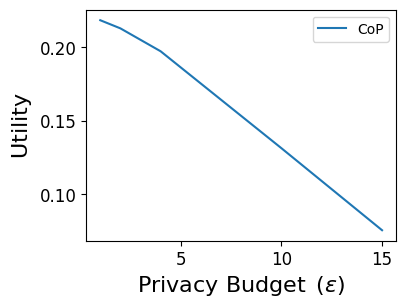

In [7]:
mse_loss = []

for eps in EPS_ARRAY:
    with open(f"{os.getcwd()}/results/dummy_utility_evaluation_eps_{eps}.pkl", 'rb') as file:
        mse_loss.append(pickle.load(file)["_0_1_loss"])

plt.figure(figsize=(4, 3))

plt.plot(EPS_ARRAY, mse_loss)
plt.legend(['CoP'], fontsize=10)

plt.xlabel(r"$\operatorname{Privacy \ Budget}$ $(\epsilon)$", fontsize=16)
plt.ylabel(r"$\operatorname{Utility}$", fontsize=16)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12) 